# Adaptive 3D Gaussian Splatting

This notebook implements **Adaptive Density Control** for a differentiable 3D Gaussian Splatting rasterizer. 
It demonstrates how a model can dynamically "grow" and "prune" geometry during training to better fit the target scene.

## Theoretical Background

In ["3D Gaussian Splatting for Real-Time Radiance Field Rendering"](https://repo-sam.inria.fr/fungraph/3d-gaussian-splatting/), the authors introduce a strategy to adaptively control the number of Gaussians. 
Static point clouds often lack detail in some areas or have too many points in empty space. The optimization solves this by monitoring the **view-space positional gradients** ($\nabla_{p} L$) of each Gaussian.

### 1. Under-Reconstruction (Cloning)
If a Gaussian has a high gradient but a **small scale**, it means it is trying to reconstruct a detail that is too small for it, or it is in a "hole" that needs filling.
*   **Action**: **Clone** the Gaussian (duplicate it).
*   **Effect**: Creates two overlapping Gaussians that can move apart to cover the area.

### 2. Over-Reconstruction (Splitting)
If a Gaussian has a high gradient and a **large scale**, it is likely a huge "floater" or a single Gaussian trying to cover a complex shape with high variance.
*   **Action**: **Split** the Gaussian into two smaller ones.
*   **Effect**: Divides the large Gaussian into smaller, finer details. Scale is reduced by a factor (e.g., $\phi=1.6$).

### 3. Pruning
To remove artifacts and floaters, we remove Gaussians that:
*   Have very low **opacity** ($\alpha < \epsilon$), meaning they don't contribute to the image.
*   Are too large (scale > scene bounds), which typically indicates disparate floaters.

## Implementation Overview
We use a `SimpleGaussianModel` class to manage the parameters:
*   **`_xyz`, `_rotation`, `_scale`, `_opacity`, `_color`**: Learnable parameters.
*   **Activations**: We store *raw* parameters (logits/logs) and apply activations (`sigmoid`, `exp`) during the forward pass to maintain valid ranges.
*   **`densify_and_prune`**: The core function that checks gradients and scales to add/remove points.


In [1]:
import torch
import torch.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
torch.manual_seed(42)
device = torch.device('cpu') # Using CPU for this educational demo
print(f"Using device: {device}")


Using device: cpu


## 1. Differentiable Rasterizer Primitives
These helper functions implement the core math of projecting 3D Gaussians to 2D splats.
See the `pytorch3DGS.ipynb` notebook for a detailed derivation of `compute_2d_covariance`.


In [2]:
def build_rotation(r):
    # Normalize quaternion to valid rotation
    norm = torch.sqrt(r[:,0]*r[:,0] + r[:,1]*r[:,1] + r[:,2]*r[:,2] + r[:,3]*r[:,3])
    q = r / norm[:, None]
    R = torch.zeros((q.shape[0], 3, 3), device=device)
    r = q[:, 0]; x = q[:, 1]; y = q[:, 2]; z = q[:, 3]
    R[:, 0, 0] = 1 - 2 * (y*y + z*z)
    R[:, 0, 1] = 2 * (x*y - r*z)
    R[:, 0, 2] = 2 * (x*z + r*y)
    R[:, 1, 0] = 2 * (x*y + r*z)
    R[:, 1, 1] = 1 - 2 * (x*x + z*z)
    R[:, 1, 2] = 2 * (y*z - r*x)
    R[:, 2, 0] = 2 * (x*z - r*y)
    R[:, 2, 1] = 2 * (y*z + r*x)
    R[:, 2, 2] = 1 - 2 * (x*x + y*y)
    return R

def build_scaling(s):
    S = torch.zeros((s.shape[0], 3, 3), device=device)
    S[:, 0, 0] = s[:, 0]
    S[:, 1, 1] = s[:, 1]
    S[:, 2, 2] = s[:, 2]
    return S

def compute_covariance_3d(scaling, quaternion):
    # Sigma = R * S * S^T * R^T
    R = build_rotation(quaternion)
    S = build_scaling(scaling)
    M = torch.bmm(R, S)
    return torch.bmm(M, M.transpose(1, 2))

def compute_2d_covariance(covariance_3d, view_matrix, world_pos, width, height, tan_fovx, tan_fovy):
    # Projects 3D Covariance (Sigma) to 2D (Sigma') using Jacobian J and View Matrix W
    # Sigma' = J * W * Sigma * W^T * J^T
    R_view = view_matrix[:3, :3] 
    t_view = view_matrix[:3, 3]
    pos_view = torch.matmul(world_pos, R_view.T) + t_view
    x, y, z = pos_view[:, 0], pos_view[:, 1], pos_view[:, 2]
    
    focal_x = width / (2.0 * tan_fovx)
    focal_y = height / (2.0 * tan_fovy)
    z = torch.clamp(z, min=0.001) # Avoid division by zero
    
    J = torch.zeros((world_pos.shape[0], 2, 3), device=device)
    J[:, 0, 0] = focal_x / z
    J[:, 0, 2] = -(focal_x * x) / (z * z)
    J[:, 1, 1] = focal_y / z
    J[:, 1, 2] = -(focal_y * y) / (z * z)
    
    W = R_view.unsqueeze(0).expand(world_pos.shape[0], 3, 3)
    T = torch.bmm(J, W)
    cov2d = torch.bmm(T, torch.bmm(covariance_3d, T.transpose(1, 2)))
    
    # Low-pass filter to prevent aliasing
    cov2d[:, 0, 0] += 0.3; cov2d[:, 1, 1] += 0.3
    return cov2d, pos_view


## 2. Rasterization Loop
This function renders the scene.
*   **Sorting**: Sorts Gaussians by depth (back-to-front or front-to-back depending on blending implementation).
*   **Splatting**: evaluating the 2D Gaussian equation for each pixel in the bounding box.
*   **Autograd**: Note `canvas = canvas.clone()`. This is crucial for PyTorch's autograd to track the history of the image generation properly without in-place errors.


In [3]:
def differentiable_rasterizer(world_pos, colors, opacities, scales, rots, width, height):
    # Camera setup (Simple fixed camera looking at origin)
    fov_y = 60.0
    tan_fovy = math.tan(math.radians(fov_y) * 0.5)
    tan_fovx = tan_fovy * (width / height)
    view_mat = torch.eye(4, device=device)
    view_mat[2, 3] = -5.0 # View Fix (Script) # Move camera back 5 units
    view_mat = torch.inverse(view_mat)
    
    # Compute 2D Projections
    cov3d = compute_covariance_3d(scales, rots)
    cov2d, pos_view = compute_2d_covariance(cov3d, view_mat, world_pos, width, height, tan_fovx, tan_fovy)
    
    # Screen space coordinates
    focal_x = width / (2.0 * tan_fovx)
    focal_y = height / (2.0 * tan_fovy)
    screen_x = (pos_view[:, 0] / pos_view[:, 2]) * focal_x + width / 2.0
    screen_y = (pos_view[:, 1] / pos_view[:, 2]) * focal_y + height / 2.0
    
    # Depth Sorting
    depths = pos_view[:, 2]
    sorted_idx = torch.argsort(depths, descending=True) # Back-to-front rendering order
    
    # Setup Grid
    y_grid, x_grid = torch.meshgrid(torch.arange(height, device=device), torch.arange(width, device=device), indexing='ij')
    canvas = torch.zeros((height, width, 3), device=device)
    
    # Iterate and Splat
    for idx in sorted_idx:
        canvas = canvas.clone() # Clone to avoid in-place operation error in Autograd
        
        mu = torch.stack([screen_x[idx], screen_y[idx]])
        sigma = cov2d[idx]
        color = colors[idx]
        opacity = opacities[idx]
        
        try: inv_sigma = torch.inverse(sigma)
        except RuntimeError: continue
        
        # Compute Bounding Box (3-sigma rule)
        radius = 3.0 * torch.sqrt(torch.max(torch.abs(sigma)))
        radius = torch.clamp(radius, min=1.0, max=width)
        
        min_x = int(torch.clamp(mu[0] - radius, 0, width).item())
        max_x = int(torch.clamp(mu[0] + radius, 0, width).item())
        min_y = int(torch.clamp(mu[1] - radius, 0, height).item())
        max_y = int(torch.clamp(mu[1] + radius, 0, height).item())
        
        if max_x <= min_x or max_y <= min_y: continue
            
        # Gaussian Evaluation
        grid_x_slice = x_grid[min_y:max_y, min_x:max_x].float()
        grid_y_slice = y_grid[min_y:max_y, min_x:max_x].float()
        dx = grid_x_slice - mu[0]
        dy = grid_y_slice - mu[1]
        
        # Power = -0.5 * (x-u)^T * Sigma^-1 * (x-u)
        power = -0.5 * (inv_sigma[0, 0] * dx * dx + 2 * inv_sigma[0, 1] * dx * dy + inv_sigma[1, 1] * dy * dy)
        alpha_splat = torch.exp(power) * opacity
        alpha_splat = alpha_splat.unsqueeze(-1)
        
        # Alpha Blending
        current_bg = canvas[min_y:max_y, min_x:max_x].clone()
        blended_slice = color * alpha_splat + current_bg * (1.0 - alpha_splat)
        canvas[min_y:max_y, min_x:max_x] = blended_slice
        
    return canvas


## 3. The Gaussian Model & Adaptive Logic
This class encapsulates the state of the Gaussians.
Crucially, it handles `densify_and_prune`, which applies the Split/Clone/Prune logic.

**Note on Activations**:
To ensure parameters remain valid (e.g., scale > 0, opacity in [0,1]), we optimize in a different space and apply activations:
*   `scale`: stored as `log(scale)`. Activation: `torch.exp`.
*   `opacity`: stored as `logit(opacity)`. Activation: `torch.sigmoid`.
*   `color`: stored as `logit(color)`. Activation: `torch.sigmoid`.


In [4]:
class SimpleGaussianModel:
    def __init__(self, N=5):
        # Initialize with N random points
        self._xyz = nn.Parameter(torch.rand(N, 3, device=device) * 2.0 - 1.0)
        self._xyz.data[:, 2] = 0.0 # Initialize flat at Z=0
        
        self._rotation = nn.Parameter(torch.rand(N, 4, device=device)) 
        self._rotation.data[:, 0] = 1.0 # Identity quaternion init
        
        # Scale: Log space. Init around 0.1 -> log(0.1) ~ -2.3
        self._scale = nn.Parameter(torch.ones(N, 3, device=device) * -2.3)
        
        # Opacity: Logit space. Init 0.5 -> logit(0.5) = 0.0
        self._opacity = nn.Parameter(torch.zeros(N, 1, device=device))
        
        # Color: Logit space. Init grey (0.0 means 0.5 sigmoid)
        self._color = nn.Parameter(torch.zeros(N, 3, device=device))
        
        # Gradient stats for adaptivity
        self.xyz_gradient_accum = torch.zeros(N, device=device)
        self.denom = torch.zeros(N, device=device)

    def parameters(self):
        return [self._xyz, self._rotation, self._scale, self._opacity, self._color]

    def reset_stats(self):
        self.xyz_gradient_accum = torch.zeros(self._xyz.shape[0], device=device)
        self.denom = torch.zeros(self._xyz.shape[0], device=device)

    def densify_and_prune(self, max_grad, min_opacity, extent, grow_percent):
        """
        The Main Adaptive Logic:
        1. Check average gradients accumulated over the densification interval.
        2. Clone points with high gradient AND small scale.
        3. Split points with high gradient AND large scale.
        4. Prune points with low opacity or excessive scale.
        """
        grads = self.xyz_gradient_accum / self.denom
        grads[grads.isnan()] = 0.0
        
        # Get activated values for logic checks
        scales = torch.exp(self._scale)
        opacities = torch.sigmoid(self._opacity)
        
        # 1. Identify Candidates
        max_scale = torch.max(scales, dim=1).values
        # Clone: High Gradient + Small Scale (Under-reconstructed region)
        mask_clone = (grads >= max_grad) & (max_scale <= grow_percent * extent)
        # Split: High Gradient + Large Scale (Over-reconstructed / covering too much)
        mask_split = (grads >= max_grad) & (max_scale > grow_percent * extent)
        
        # Collect new parameters (Start with those NOT being split)
        # We KEEP originals for Clones (so we just append copies)
        # We DISCARD originals for Splits (so we exclude them from init list)
        new_xyz_list = [self._xyz[~mask_split]]
        new_rot_list = [self._rotation[~mask_split]]
        new_scale_list = [self._scale[~mask_split]]
        new_op_list = [self._opacity[~mask_split]]
        new_col_list = [self._color[~mask_split]]

        # --- Perform Cloning ---
        if mask_clone.any():
            print(f"Cloning {mask_clone.sum().item()} gaussians")
            # Append exact copies of the selected gaussians
            new_xyz_list.append(self._xyz[mask_clone])
            new_rot_list.append(self._rotation[mask_clone])
            new_scale_list.append(self._scale[mask_clone])
            new_op_list.append(self._opacity[mask_clone])
            new_col_list.append(self._color[mask_clone])

        # --- Perform Splitting ---
        if mask_split.any():
            print(f"Splitting {mask_split.sum().item()} gaussians")
            stds = scales[mask_split]
            means = self._xyz[mask_split]
            
            # Split into 2 samples per original
            samples = 2
            stds = stds.repeat(samples, 1)
            means = means.repeat(samples, 1)
            
            # Sample positions from the Gaussian distribution
            noise = (torch.rand(means.shape, device=device) - 0.5) * (stds * 0.1) 
            split_xyz = means + noise 
            
            # Reduce scale: new_scale = old_scale / 1.6
            # In log space: new_log = old_log - log(1.6)
            split_scale = self._scale[mask_split].repeat(samples, 1) - math.log(1.6)
            
            # Duplicate other attributes
            split_rot = self._rotation[mask_split].repeat(samples, 1)
            split_op = self._opacity[mask_split].repeat(samples, 1)
            split_col = self._color[mask_split].repeat(samples, 1)

            new_xyz_list.append(split_xyz)
            new_rot_list.append(split_rot)
            new_scale_list.append(split_scale)
            new_op_list.append(split_op)
            new_col_list.append(split_col)

        # --- Reconstruct Parameters ---
        self._xyz = nn.Parameter(torch.cat(new_xyz_list, dim=0))
        self._rotation = nn.Parameter(torch.cat(new_rot_list, dim=0))
        self._scale = nn.Parameter(torch.cat(new_scale_list, dim=0))
        self._opacity = nn.Parameter(torch.cat(new_op_list, dim=0))
        self._color = nn.Parameter(torch.cat(new_col_list, dim=0))

        # --- Perform Pruning ---
        current_ops = torch.sigmoid(self._opacity)
        current_scales = torch.exp(self._scale)
        
        # Prune if opacity is too low OR scale is insanely huge (floater)
        min_op_mask = (current_ops.squeeze() >= min_opacity)
        max_scale_keep = (torch.max(current_scales, dim=1).values < extent * 1.0)
        mask_keep = min_op_mask & max_scale_keep
        
        if not mask_keep.all():
            # Safety Check: Never prune ALL points (stops training crash)
            if mask_keep.sum() == 0 and self._xyz.shape[0] > 0:
                 mask_keep[0] = True
            
            prune_count = (~mask_keep).sum().item()
            if prune_count > 0:
                print(f"Pruning {prune_count} gaussians")
                self._xyz = nn.Parameter(self._xyz[mask_keep])
                self._rotation = nn.Parameter(self._rotation[mask_keep])
                self._scale = nn.Parameter(self._scale[mask_keep])
                self._opacity = nn.Parameter(self._opacity[mask_keep])
                self._color = nn.Parameter(self._color[mask_keep])
        
        self.reset_stats()


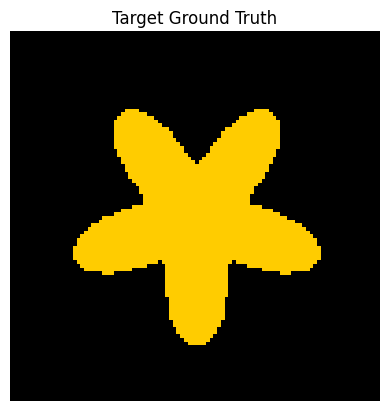

In [5]:
def create_target_shape(W, H):
    """Creates a 2D 'Star' shape target image."""
    yv, xv = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
    x = (xv - W/2) / (W/2)
    y = (yv - H/2) / (H/2)
    r = torch.sqrt(x**2 + y**2)
    t = torch.atan2(y, x)
    # Parametric star shape
    shape_mask = r < (0.5 + 0.2 * torch.sin(5*t))
    
    img = torch.zeros((H, W, 3), device=device)
    img[shape_mask] = torch.tensor([1.0, 0.8, 0.0]) # Gold color
    return img

W, H = 100, 100
target_img = create_target_shape(W, H)
plt.imshow(target_img.cpu().numpy())
plt.title("Target Ground Truth")
plt.axis('off')
plt.show()


## 4. Optimization Loop with Adaptivity
We train the model to match the `target_img`.
*   **Loss**: Simple L1 Loss (Pixel difference).
*   **Gradient Accumulation**: After `loss.backward()`, we store the norm of the position gradients.
*   **Densification**: Every 100 steps, we call `densify_and_prune`. This alters the size of the parameter tensors, so we **must re-create the optimizer** to track the new parameters.


Starting Training...
Iter 0, Loss: 0.1279, Points: 5
--- Iter 100 ---
Splitting 5 gaussians
Iter 100, Loss: 0.0912, Points: 10
--- Iter 200 ---
Splitting 10 gaussians
Iter 200, Loss: 0.0575, Points: 20
--- Iter 300 ---
Splitting 20 gaussians
Iter 300, Loss: 0.0381, Points: 40
--- Iter 400 ---
Splitting 37 gaussians
Iter 400, Loss: 0.0240, Points: 77
--- Iter 500 ---
Cloning 2 gaussians
Splitting 53 gaussians
Iter 500, Loss: 0.0140, Points: 132
--- Iter 600 ---
Cloning 13 gaussians
Splitting 42 gaussians
Iter 600, Loss: 0.0087, Points: 187


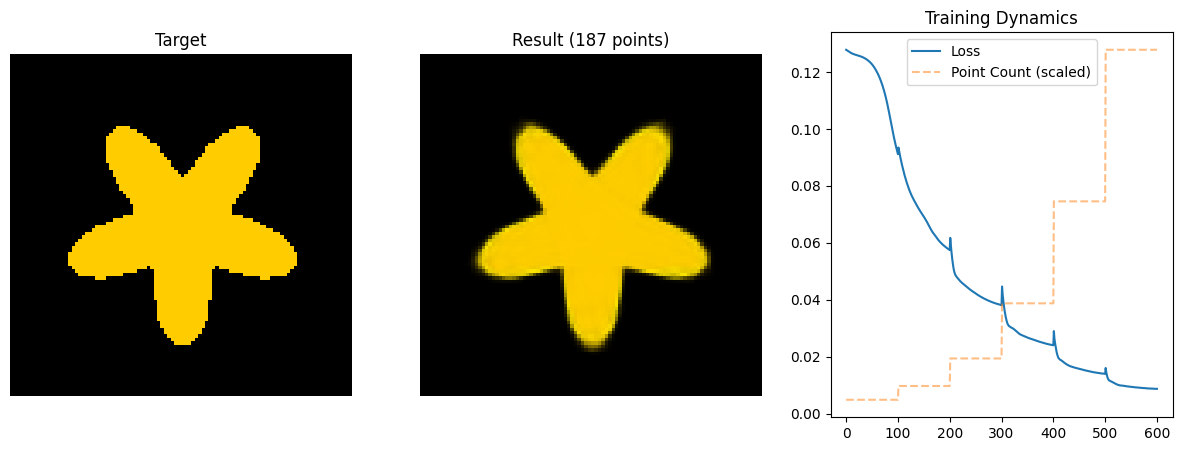

In [6]:
model = SimpleGaussianModel(N=5) # Start extremely sparse (5 points)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

iterations = 601
densify_interval = 100
history_loss = []
debug_counts = []

print("Starting Training...")
for i in range(iterations):
    optimizer.zero_grad()
    
    # 1. Forward Pass (Apply activations!)
    render = differentiable_rasterizer(
        model._xyz, 
        torch.sigmoid(model._color), 
        torch.sigmoid(model._opacity), 
        torch.exp(model._scale), 
        model._rotation, 
        W, H
    )
    
    # 2. Compute Loss
    loss = torch.abs(render - target_img).mean()
    loss.backward()
    
    # 3. Accumulate Gradients for Adaptivity
    with torch.no_grad():
        # We care about gradients of the means (xyz)
        model.xyz_gradient_accum += torch.norm(model._xyz.grad, dim=1)
        model.denom += 1
    
    optimizer.step()
    history_loss.append(loss.item())
    debug_counts.append(model._xyz.shape[0])
    
    # 4. Adaptive Density Control
    if i > 0 and i % densify_interval == 0:
        print(f"--- Iter {i} ---")
        # densify_and_prune changes the number of parameters!
        model.densify_and_prune(
            max_grad=0.0002,     # Threshold: if grad > 0.0002, clone/split
            min_opacity=0.05,    # Threshold: if opacity < 0.05, prune
            extent=2.0,          # Scene bounds estimate
            grow_percent=0.05    # Scale threshold for split vs clone
        )
        
        # IMPORTANT: Since parameters (tensors) are replaced, old optimizer holds dead references.
        # We must create a new optimizer with the new parameters.
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01) 
        
    if i % 100 == 0:
        print(f"Iter {i}, Loss: {loss.item():.4f}, Points: {model._xyz.shape[0]}")

# Visualization
plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(target_img.cpu()); plt.title("Target")
plt.axis('off')
plt.subplot(1,3,2); plt.imshow(render.detach().cpu()); plt.title(f"Result ({model._xyz.shape[0]} points)")
plt.axis('off')
plt.subplot(1,3,3); plt.plot(history_loss, label='Loss'); 
plt.plot(np.array(debug_counts)/max(debug_counts)*max(history_loss), label='Point Count (scaled)', alpha=0.5, linestyle='--')
plt.legend(); plt.title("Training Dynamics")
plt.show()
